In [24]:
import pandas as pd
df = pd.read_csv("train.csv")

In [25]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [26]:
#Check for missing values before analysis
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [27]:
#Check for missing values in the "Fare" column before analysis
df["Fare"].isna().sum()

np.int64(0)

In [28]:
#Check for missing values in the "Sex" column before analysis
df["Sex"].isna().sum()

np.int64(0)

In [29]:
# Compute average fare charge by gender
df.groupby("Sex")["Fare"].mean()

Sex
female    44.479818
male      25.523893
Name: Fare, dtype: float64

In [30]:
#Check for missing values in the "Survived" column before analysis
df["Survived"].isna().sum()

np.int64(0)

In [31]:
# Compute survival rate by gender
df.groupby("Sex")["Survived"].sum()

Sex
female    233
male      109
Name: Survived, dtype: int64

In [32]:
is_male = df["Sex"] == "male"

In [33]:
is_female = df["Sex"] == "female"

In [34]:
is_male.sum()

np.int64(577)

In [35]:
is_female.sum()

np.int64(314)

In [36]:
df.groupby(["Sex","Pclass"])["Survived"].sum()
df.groupby(["Sex","Pclass"])["Survived"].count()
grouped = df.groupby(["Sex","Pclass"])["Survived"]
survived = grouped.sum()
total = grouped.count()
rates = survived/total
print(rates)

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64


In [37]:
males = df[df["Sex"] == "male"]
males.groupby("Pclass")["Survived"].mean()

Pclass
1    0.368852
2    0.157407
3    0.135447
Name: Survived, dtype: float64

In [38]:
df.groupby(["Pclass","Sex"])["Survived"].mean().unstack()

Sex,female,male
Pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


In [39]:
# Identifies deck level based off Cabin number
df["Deck"] = df["Cabin"].str[0]
df["Deck"] = df["Deck"].fillna("Unknown")

In [40]:
# Compute survival rate by Deck Level
df.groupby("Deck")["Survived"].mean()

Deck
A          0.466667
B          0.744681
C          0.593220
D          0.757576
E          0.750000
F          0.615385
G          0.500000
T          0.000000
Unknown    0.299854
Name: Survived, dtype: float64

In [41]:
# Create family size feature using number of relatives aboard
df["FSize"] = df["SibSp"] + df["Parch"] + 1
print(df["FSize"])
# Compute survival rate by Family Size
df.groupby("FSize")["Survived"].mean()
df.groupby(["Pclass","FSize"])["Survived"].mean()

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: FSize, Length: 891, dtype: int64


Pclass  FSize
1       1        0.532110
        2        0.728571
        3        0.750000
        4        0.714286
        5        1.000000
        6        0.500000
2       1        0.346154
        2        0.529412
        3        0.677419
        4        0.769231
        5        1.000000
        6        1.000000
3       1        0.212963
        2        0.350877
        3        0.425532
        4        0.666667
        5        0.000000
        6        0.000000
        7        0.333333
        8        0.000000
        11       0.000000
Name: Survived, dtype: float64

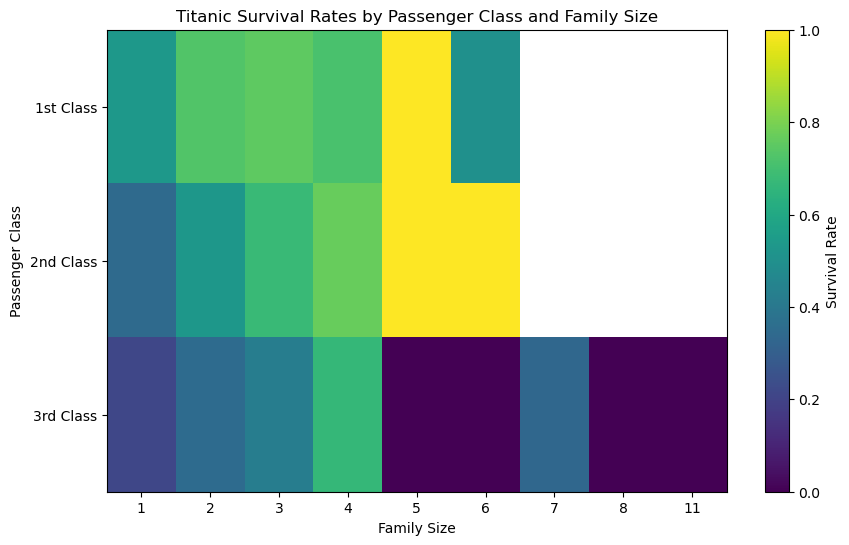

In [42]:
# Create a pivot table to analyze survival rates by passenger class and family size
pivot = df.pivot_table(
    values="Survived",
    index="Pclass",
    columns="FSize",
    aggfunc="mean"
)
import matplotlib.pyplot as plt

# Create a heatmap-style visualization of the survival rates
plt.figure(figsize=(10,6))

# Plot the survival rate matrix using a color scale from 0 to 1
plt.imshow(pivot, aspect="auto", cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="Survival Rate")

# Label the axes with family size and passenger class
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), ["1st Class","2nd Class","3rd Class"])

# Add labels and title
plt.xlabel("Family Size")
plt.ylabel("Passenger Class")
plt.title("Titanic Survival Rates by Passenger Class and Family Size")

# Display the visualization
plt.show()

In [43]:
# Group family sizes to stabilize survival estimates
df["FamilyGroup"] = pd.cut(
    df["FSize"],
    bins=[0,1,4,20],
    labels=["Single","Small Family","Large Family"]
)
# Compute survival rate by sorted Family Size
df.groupby("FamilyGroup")["Survived"].mean()

C:\Users\Owner\AppData\Local\Temp\ipykernel_25028\2554870598.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("FamilyGroup")["Survived"].mean()


FamilyGroup
Single          0.303538
Small Family    0.578767
Large Family    0.161290
Name: Survived, dtype: float64

Findings:
Females had much higher survival rates than males. About 74% of females survived compared to about 19% of males. 
First class passengers had much higher survival rates than second and third class passengers. Even when only looking at males, first class men still survived at higher rates than men in lower classes. 
Survival rates varied by family size. Passengers traveling in small families (2–4 people) had the highest survival rate (~58%), while solo travelers (~30%) and large families (~16%) had lower survival rates. Very large families sometimes showed unusual survival rates, but this is likely due to small sample sizes, meaning there were very few passengers in those groups. 
Even after accounting for family size, passenger class still had a strong effect on survival, with first class passengers generally surviving more often.